Week 17 · Day 1 — Intro to Generative Modeling
Why this matters

Generative models let AI create — images, voices, text, even worlds. Understanding how they model data distributions is the foundation of creative AI systems (GANs, VAEs, Diffusion).

Theory Essentials

Generative vs Discriminative Models:

Discriminative → P(y | x): classify or predict labels.

Generative → P(x): learn how data itself is distributed.

Latent Space z: compressed hidden representation that encodes variations.

Sampling: draw z ∼ N(0, I), then generate x = f(z).

Training Goal: make the model’s generated x match the true data distribution.

Applications: image synthesis, data augmentation, anomaly detection, art creation.

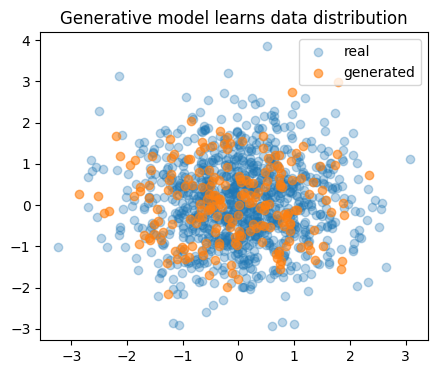

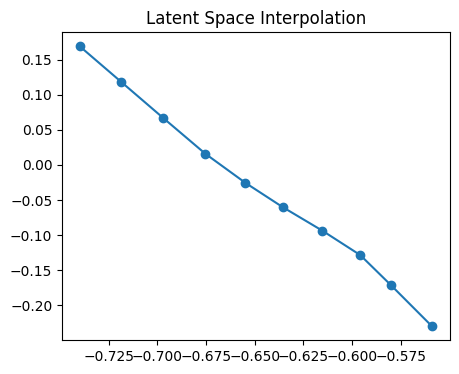

In [1]:
# Setup
import numpy as np, matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

np.random.seed(42)
plt.rcParams["figure.figsize"] = (5,4)

# 1. Create 2D Gaussian data
n = 1000
data = np.random.randn(n, 2)

# 2. Train a small MLP to learn mapping z->x (identity for now)
X, y = data, data
mlp = MLPRegressor(hidden_layer_sizes=(32,32), max_iter=500, random_state=42)
mlp.fit(X, y)

# 3. Generate new samples
z_new = np.random.randn(200, 2)
x_gen = mlp.predict(z_new)

# 4. Visualize
plt.scatter(data[:,0], data[:,1], alpha=0.3, label='real')
plt.scatter(x_gen[:,0], x_gen[:,1], alpha=0.6, label='generated')
plt.legend(); plt.title("Generative model learns data distribution")
plt.show()

# 5. Latent interpolation
z1, z2 = np.random.randn(1,2), np.random.randn(1,2)
interps = np.linspace(0,1,10).reshape(-1,1)*(z2-z1)+z1
x_interp = mlp.predict(interps)
plt.plot(x_interp[:,0], x_interp[:,1], 'o-')
plt.title("Latent Space Interpolation")
plt.show()



### 🧠 Theory Recap

**Goal of generative models:**
Instead of predicting labels (like “cat” or “dog”), we want the model to **learn how data itself is distributed** — i.e., to *generate new samples* that look like the real ones.

| Model type         | Learns...                               | Example task                       |                 |
| ------------------ | --------------------------------------- | ---------------------------------- | --------------- |
| **Discriminative** | ( P(y                                   | x) ): boundaries between classes   | Classify images |
| **Generative**     | ( P(x) ): what *data itself* looks like | Generate new images that look real |                 |

Generative models learn to **sample** from a distribution — for instance, learning what “handwritten digits” look like, then producing new digits that never existed before.

---

### 🧩 Step-by-Step Through Your Code

```python
# 1. Create 2D Gaussian data
n = 1000
data = np.random.randn(n, 2)
```

You create **real data** — 1000 points from a 2D Gaussian distribution (like a blob centered at 0).
That’s your “real world” — what we want the model to learn.

---

```python
# 2. Train a small MLP to learn mapping z->x (identity for now)
X, y = data, data
mlp = MLPRegressor(hidden_layer_sizes=(32,32), max_iter=500, random_state=42)
mlp.fit(X, y)
```

Here:

* You feed the same data as input **and** target (`X=y=data`).
* The MLP tries to **learn the identity function**: output ≈ input.
  So the model learns a function ( f(z) = x ) that reproduces the distribution of real data.

This mimics what a **generator** in a GAN does — mapping a *latent vector* ( z ) to a *sample* ( x ).

---

```python
# 3. Generate new samples
z_new = np.random.randn(200, 2)
x_gen = mlp.predict(z_new)
```

Now we draw **new random latent vectors** ( z ) from the same Gaussian and pass them through the trained MLP.
→ The MLP outputs “fake” points, which should look similar to real ones.

---

```python
plt.scatter(data[:,0], data[:,1], alpha=0.3, label='real')
plt.scatter(x_gen[:,0], x_gen[:,1], alpha=0.6, label='generated')
```

This creates your first plot.

✅ **Interpretation:**

* Blue = real data
* Orange = generated points
  If the MLP has learned the distribution, both overlap closely — showing the model can now *generate* similar data.

---

```python
# 5. Latent interpolation
z1, z2 = np.random.randn(1,2), np.random.randn(1,2)
interps = np.linspace(0,1,10).reshape(-1,1)*(z2-z1)+z1
x_interp = mlp.predict(interps)
plt.plot(x_interp[:,0], x_interp[:,1], 'o-')
```

Here we pick two random latent points ( z_1 ) and ( z_2 ),
then linearly interpolate between them → trace a smooth path through latent space.
Each step generates a new output ( x = f(z) ).

✅ **Interpretation:**
This shows **latent space smoothness** — small moves in ( z )-space create smooth transitions in generated data.
In real generative models (like VAEs or GANs), this is how AI morphs between images or styles.

---

### 🖼 What You’re Seeing

1. **First plot:**
   The MLP learned to reproduce the *shape* of the data distribution — the orange (generated) overlaps with blue (real).

2. **Second plot:**
   The interpolation shows the *continuity* of the latent space: the model produces a smooth path between two generated samples.

---

### 💡 Why It Matters

This is a *toy example* of what GANs, VAEs, and Diffusion models do — but in millions of dimensions:

* The **generator** maps random noise → realistic data.
* The **latent space** captures variations (e.g., faces smiling → neutral → sad).
* The **goal** is to make generated samples indistinguishable from real ones.



### 🧭 What those 10 dots actually are

Each **dot** in that line corresponds to **one generated data point** —
the result of passing a slightly different **latent vector z** through the model.

Here’s the sequence:

1. You randomly pick two latent points:

   ```python
   z1, z2 = np.random.randn(1,2), np.random.randn(1,2)
   ```

   These are just two random positions in the **latent space** (think: two “ideas” in the model’s imagination).

2. Then you interpolate (create 10 evenly spaced points) **between** them:

   ```python
   interps = np.linspace(0,1,10).reshape(-1,1)*(z2-z1)+z1
   ```

   So now you have 10 points that go smoothly from `z1` → `z2`.

3. For each of these 10 latent vectors, you generate an output:

   ```python
   x_interp = mlp.predict(interps)
   ```

   → Each row of `x_interp` is a *generated sample* ( x = f(z) ).

---

### 🧩 What the line plot shows

* The **x- and y-axes** are the 2D coordinates of those generated samples.
* The **dots** (`o`) are the generated points.
* The **line** (`-`) connects them in order, showing how the output moves as you slide through the latent space.

So visually, you’re seeing the *path that the generated outputs take* when you move smoothly between two latent vectors.

---

### 💡 Intuitive meaning

* Each dot = one generated example.
* Connecting them shows **how the generated output changes gradually** as you move in the hidden (latent) space.
* If the path is smooth and continuous → your model learned a *coherent latent space* (similar inputs → similar outputs).

In more complex generative models (like VAEs or GANs), this plot becomes powerful:
you can see faces morph, objects rotate, or digits transition from “2” → “3” → “4” smoothly.

---

So yes:
✅ each dot = one generated data point
✅ the line = smooth “walk” through the model’s internal imagination


1) Core (10 min)
Task: Change the data to a 2D ring distribution (r = 1 + 0.1 * np.random.randn(n) and theta = 2πu) and retrain.

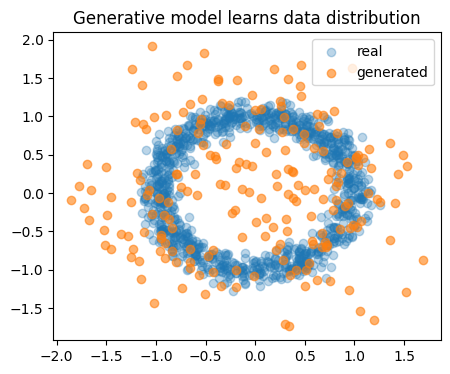

In [11]:
theta = 2*np.pi*np.random.rand(n)
r = 1 + 0.1*np.random.randn(n)
data = np.c_[r*np.cos(theta), r*np.sin(theta)]
mlp.fit(data, data)


# 3. Generate new samples
z_new = np.random.randn(200, 2)
x_gen = mlp.predict(z_new)

# 4. Visualize
plt.scatter(data[:,0], data[:,1], alpha=0.3, label='real')
plt.scatter(x_gen[:,0], x_gen[:,1], alpha=0.6, label='generated')
plt.legend(); plt.title("Generative model learns data distribution")
plt.show()

2) Practice (15 min)
Task: Add one more hidden layer and observe sample diversity.

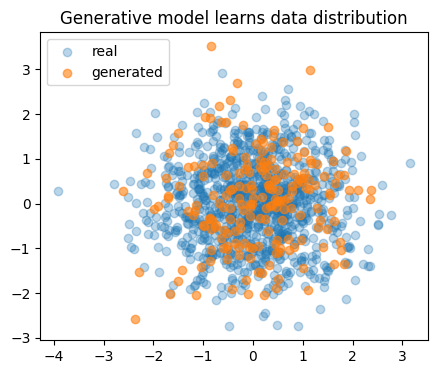

In [13]:
n = 1000
data = np.random.randn(n, 2)

# 2. Train a small MLP to learn mapping z->x (identity for now)
X, y = data, data
mlp = MLPRegressor(hidden_layer_sizes=(64,32,16), max_iter=800)
mlp.fit(data, data)

# 3. Generate new samples
z_new = np.random.randn(200, 2)
x_gen = mlp.predict(z_new)

# 4. Visualize
plt.scatter(data[:,0], data[:,1], alpha=0.3, label='real')
plt.scatter(x_gen[:,0], x_gen[:,1], alpha=0.6, label='generated')
plt.legend(); plt.title("Generative model learns data distribution")
plt.show()


3) Stretch (10 min, optional)
Task: Train on a mixture of two Gaussians.

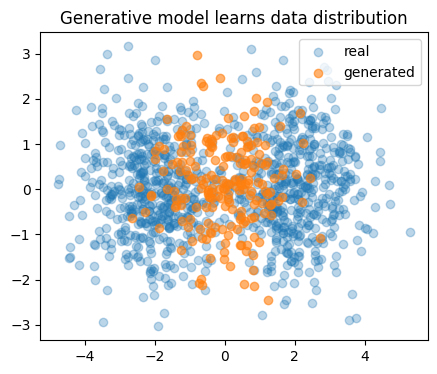

In [14]:
data = np.vstack([np.random.randn(n//2,2)+[2,0],
                  np.random.randn(n//2,2)-[2,0]])
mlp.fit(data, data)

z_new = np.random.randn(200, 2)
x_gen = mlp.predict(z_new)

# 4. Visualize
plt.scatter(data[:,0], data[:,1], alpha=0.3, label='real')
plt.scatter(x_gen[:,0], x_gen[:,1], alpha=0.6, label='generated')
plt.legend(); plt.title("Generative model learns data distribution")
plt.show()


Mini-Challenge (≤ 40 min)

Goal: Visualize how latent space maps to generated space.

Steps:

Train on 2D data (e.g., ring or two clusters).

Generate a grid of z points (e.g., [-2, 2]×[-2, 2]).

Plot model output for each z to see the learned structure.

Acceptance Criteria:

Clear scatter plot showing latent grid → output mapping.

Short note (2–3 lines) explaining how model captures distribution.

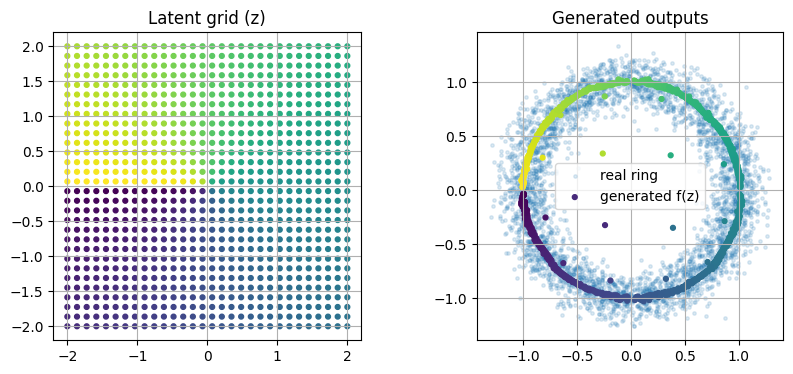

In [17]:
import numpy as np, matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor

np.random.seed(42)
plt.rcParams["figure.figsize"] = (10,4); plt.rcParams["axes.grid"] = True

# 1) Latent inputs (cover the space you'll probe)
n = 6000
z_train = np.random.uniform(-2, 2, size=(n, 2))   # not Gaussian now; matches your grid

# 2) Deterministic targets on a ring from z's angle
angle = np.arctan2(z_train[:,1], z_train[:,0])
r = 1 + 0.05*np.random.randn(n)                   # small radius noise
x_train = np.c_[r*np.cos(angle), r*np.sin(angle)] # ring point = f(z)

# 3) Train mapper f: z -> x
mlp = MLPRegressor(hidden_layer_sizes=(128,128), activation="relu",
                   max_iter=2000, random_state=42)
mlp.fit(z_train, x_train)

# 4) Probe a grid and visualize
g = np.linspace(-2, 2, 30)
Zx, Zy = np.meshgrid(g, g)
z_grid = np.c_[Zx.ravel(), Zy.ravel()]
x_grid = mlp.predict(z_grid)
colors = np.arctan2(z_grid[:,1], z_grid[:,0])

# real ring for reference
theta = 2*np.pi*np.random.rand(4000); r0 = 1 + 0.12*np.random.randn(4000)
x_real = np.c_[r0*np.cos(theta), r0*np.sin(theta)]

fig, axs = plt.subplots(1,2,figsize=(10,4))
axs[0].scatter(z_grid[:,0], z_grid[:,1], c=colors, s=12); axs[0].set_aspect('equal')
axs[0].set_title("Latent grid (z)")
axs[1].scatter(x_real[:,0], x_real[:,1], s=6, alpha=0.15, label="real ring")
axs[1].scatter(x_grid[:,0], x_grid[:,1], c=colors, s=12, label="generated f(z)")
axs[1].set_aspect('equal'); axs[1].legend(); axs[1].set_title("Generated outputs")
plt.show()


🎨 How to read your plots
Left: Latent Grid (z)

This is what you feed in — the internal coordinates.

The grid itself is completely artificial: just a clean set of evenly spaced (z₁, z₂) pairs.

Colors indicate which part of the latent space each point comes from (we color by angle so we can track them later).

Right: Generated outputs (f(z))

This is what comes out — the model’s interpretation of each z.

The same colors appear here, so you can see where each latent region ends up in output space.

For example, the yellow region (top-left z’s) maps to the top of the ring, purple maps to the bottom, etc.

👉 That’s why it’s called a mapping from latent space → data space.

🔄 Why this matters

In powerful generative models (like VAEs, GANs, or Diffusion), the latent space encodes meaningful variations:

In a face generator, moving along the latent grid might change smile intensity, hair color, or angle.

In your toy example, it changes the angle around the ring.

Your colored ring shows the model learned a smooth, continuous mapping:

Nearby points in latent space (similar z) produce nearby points on the ring (similar x).

That smoothness is what allows things like latent interpolation — walking smoothly through z-space produces smooth transitions in generated data.

🧩 Simple analogy

Think of latent space as a “map of possibilities.”
Each coordinate (z₁, z₂) is like a knob setting on a synthesizer —
and the model (the MLP) is the instrument that turns those knob settings into actual sounds (the data, x).

The grid just shows how changing those knobs systematically changes the output.

Notes / Key Takeaways

Generative models learn P(x), not P(y | x).

Latent variables capture the essence of data variation.

Sampling z from a simple distribution lets us generate new data.

MLPs can approximate these distributions for toy cases.

Tomorrow we introduce adversarial training (GANs) to make generation much sharper.

Reflection

How does learning P(x) differ from classification?

What does latent interpolation teach about the data manifold?

1. How does learning P(x) differ from classification?
Classification learns P(y|x) — it focuses on separating or labeling data based on existing categories.
Learning P(x) means modeling how the data itself is distributed, not what label it belongs to. The goal is to understand and reproduce the structure of the data (generate new samples that look real).

2. What does latent interpolation teach about the data manifold?
Latent interpolation shows that the data lies on a smooth, continuous manifold within a higher-dimensional space.
As we move smoothly in latent space, the generated samples also change smoothly — revealing that the model has learned an organized, meaningful internal representation of the data.